# 4. Quantum linear solvers and power flow

**Reading time: about 30 minutes. Prerequisite: notebook 1. Notebooks 2 and 3
are not needed — this is a different family of algorithms.**

Notebooks 1 to 3 covered combinatorial problems, where the answer is a choice
among discrete alternatives. This notebook covers the other family: solving
`A x = b`. Power flow is the reason power system research cares. DC power flow
*is* a linear system, and every Newton-Raphson iteration of AC power flow solves
one.

You will:

1. Derive the DC power flow system from the case data, in five lines.
2. Solve it with a classical solver, with HHL, and with VQLS.
3. Take HHL’s error apart into three numbers that measure different things, and
   see why reporting one of them alone is misleading.
4. Measure the condition number of real power system matrices and say what it
   costs.
5. Run AC power flow with a quantum inner solver.
6. Compare against sparse LU factorization, and state where the open research
   questions actually are.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla

import qugrid as qg
from qugrid import idx
from qugrid.problems import (
    angles_from_solution,
    dc_power_flow,
    flows_from_angles,
    newton_with_linear_solver,
)
from qugrid.solvers import solve_vqls

qg.viz.use_style()
np.set_printoptions(precision=4, suppress=True)

## 4.1 DC power flow as `A x = b`

The DC approximation makes three assumptions familiar from any power system
textbook: all voltage magnitudes equal 1 per unit, branch resistance is
negligible against reactance, and angle differences are small enough that
`sin(theta_i - theta_j)` may be replaced by `theta_i - theta_j`. The active
power flow on a branch becomes

```
P_ij = (theta_i - theta_j) / x_ij
```

Summing the flows leaving each bus and setting them equal to the net injection
gives `B' theta = P`, with

```
B'_ij = -1 / x_ij               for a branch between i and j
B'_ii = sum over branches at i of 1 / x_ij
```

`B'` is singular by construction, because adding a constant to every angle
changes no flow. Fixing the slack bus angle removes that freedom: delete the
slack row and column, and what remains is nonsingular, symmetric, and positive
definite. That is the linear system.

Take the three-bus teaching system. Bus 1 is the slack with a 90 MW generator,
bus 2 is a PV bus with a 60 MW generator, and bus 3 carries a 150 MW load.

In [2]:
net = qg.cases.toy3()
print(net)
print("branch reactances x [pu]:", net.branch[:, idx.BR_X])
print("net injection [pu]      :", np.real(net.sbus()))
print("slack bus (internal idx):", net.ref)

bbus, bf, pbusinj, pfinj = net.bdc()
print("\nfull B' (singular, includes the slack row and column):\n", bbus)

Network('toy3': 3 buses, 3 branches, 2 generators, load 150.0 MW)
branch reactances x [pu]: [0.06 0.08 0.07]
net injection [pu]      : [ 0.9  0.6 -1.5]
slack bus (internal idx): 0

full B' (singular, includes the slack row and column):
 [[ 29.1667 -16.6667 -12.5   ]
 [-16.6667  30.9524 -14.2857]
 [-12.5    -14.2857  26.7857]]


Check the entries by hand. Bus 2 connects to bus 1 through `x = 0.06` and to
bus 3 through `x = 0.07`, so `B'_22 = 1/0.06 + 1/0.07 = 30.95` and
`B'_23 = -1/0.07 = -14.29`. Both appear in the matrix above.

`dc_power_flow(net)` performs the slack elimination and returns a
`LinearSystemProblem` — the object every linear solver in QuGrid consumes.

In [3]:
problem = dc_power_flow(net)
print(problem)
print("A =\n", problem.a)
print("b =", problem.b)
print("unknowns:", problem.names, "in", problem.unit)
print("symmetric:", problem.is_hermitian)
print("condition number:", round(problem.condition_number(), 4))

LinearSystemProblem(n=2, unit='rad', cond=3)
A =
 [[ 30.9524 -14.2857]
 [-14.2857  26.7857]]
b = [ 0.6 -1.5]
unknowns: ['theta_bus2', 'theta_bus3'] in rad
symmetric: True
condition number: 3.0006


`b` is the injection vector with the slack entry removed: `+0.6` per unit at
bus 2 (60 MW of generation) and `-1.5` per unit at bus 3 (150 MW of load).

## 4.2 Three solvers, one system

`qg.solve` accepts three solvers for a linear system: `numpy` (dense LAPACK, the
reference), `hhl`, and `vqls`. Every one returns the same `Result` type.

In [4]:
reference = qg.solve(problem, solver="numpy")
print(reference.summary())
print("angles [rad]:", reference.x)

QuGrid result | solver=numpy | LinearSystemProblem(n=2)
  objective          0
  feasible           yes
  gap vs reference   0%
  residual_norm      0
  resources          wall_time_s=0.0, dimension=2
angles [rad]: [-0.0086 -0.0606]


Two helper functions map the reduced solution back to engineering quantities:
`angles_from_solution` restores the slack angle to give all-bus angles, and
`flows_from_angles` returns branch active flows in MW.

In [5]:
theta = angles_from_solution(problem, reference.x)
print("bus angles [degree]:", np.rad2deg(theta))
print("branch flows [MW]  :", flows_from_angles(problem, theta))

classical = qg.classical.solve_dc(net)
print("\nqg.classical.solve_dc agrees:", np.allclose(classical.theta, theta))
print("slack pick-up [MW]:", round(classical.slack_p_mw, 3))
print("branch loading    :", classical.loading)
print("maximum loading   :", round(classical.max_loading(), 4))

bus angles [degree]: [ 0.     -0.4911 -3.4705]
branch flows [MW]  : [14.2857 75.7143 74.2857]

qg.classical.solve_dc agrees: True
slack pick-up [MW]: 90.0
branch loading    : [0.0571 0.3029 0.2971]
maximum loading   : 0.3029


Now the two quantum solvers. HHL is the Harrow-Hassidim-Lloyd algorithm,
Physical Review Letters 2009, arXiv:0811.3171. VQLS is the Variational Quantum
Linear Solver, Bravo-Prieto et al., arXiv:1909.05820. QuGrid simulates both
exactly: HHL as the textbook circuit assembled from dense matrices, VQLS as a
shallow parameterized circuit trained by a classical optimizer.

In [6]:
for name, options in (("hhl", {"n_clock": 8}), ("vqls", {"layers": 3, "seed": 0})):
    result = qg.solve(problem, solver=name, **options)
    print(f"--- {name} {options}")
    print("   angles [rad] :", result.x)
    print("   relative error:", f"{result.decoded['relative_error']:.3e}")
    print("   resources     :", result.resources)

--- hhl {'n_clock': 8}
   angles [rad] : [-0.0087 -0.0607]
   relative error: 2.534e-03
   resources     : {'wall_time_s': 0.0032, 'n_qubits': 10, 'clock_qubits': 8, 'system_qubits': 1, 'hermitian_dilation': False, 'condition_number': 3.001}
--- vqls {'layers': 3, 'seed': 0}
   angles [rad] : [-0.0086 -0.0606]
   relative error: 1.671e-05
   resources     : {'wall_time_s': 0.027, 'n_qubits': 1, 'ansatz': 'RealAmplitudes(layers=3)', 'parameters': 4, 'evaluations': 126, 'seed': 0, 'condition_number': 3.001}


Both recover the classical answer on this system. The rest of the notebook is
about what that costs and when it stops working.

## 4.3 What HHL does, and how it fails

HHL has four stages. Each one is a place errors enter.

1. **Prepare `|b>`.** Load the injection vector into the amplitudes of a
   quantum register. Dimension `n` needs `log2(n)` qubits, rounded up, with the
   unused entries padded by an identity block.
2. **Phase estimation.** Read the eigenvalues of `A` into a second register of
   `m` **clock qubits**. This register represents eigenvalues on a grid of `2^m`
   points. An eigenvalue that does not sit exactly on that grid spreads across
   neighbouring grid points, and the amplitude that lands on the wrong point is
   lost. QuGrid reports that loss as `clock_leakage`.
3. **Invert.** Rotate an extra qubit, the ancilla, by an angle proportional to
   `1 / eigenvalue`. This is the step that turns `A` into `A^-1`. It succeeds
   only when the ancilla is later measured in state 1.
4. **Uncompute and postselect.** Undo phase estimation, then measure the
   ancilla. Runs where it reads 0 are discarded. The fraction kept is
   `success_probability`.

The clock register size `m` is the main dial. Use **even** values on this
system: an odd number of clock bits puts a grid point exactly on an eigenvalue
of this particular matrix, which produces a resonance that is interesting but
distracting on a first reading.

In [7]:
clock_bits = [4, 6, 8, 10, 12]
sweep = {}
for m in clock_bits:
    sweep[m] = qg.solve(problem, solver="hhl", n_clock=m)

print(f"{'clock':>6} {'qubits':>7} {'rel. error':>12} {'fidelity':>12} "
      f"{'P(success)':>12} {'clock leak':>12}")
for m in clock_bits:
    d = sweep[m].decoded
    print(
        f"{m:>6} {sweep[m].resources['n_qubits']:>7} {d['relative_error']:>12.2e} "
        f"{d['fidelity_vs_exact']:>12.6f} {d['success_probability']:>12.2e} "
        f"{d['clock_leakage']:>12.4f}"
    )

 clock  qubits   rel. error     fidelity   P(success)   clock leak
     4       6     2.28e-02     0.999927     6.82e-02       0.1639
     6       8     9.22e-03     0.999988     3.38e-03       0.1595
     8      10     2.53e-03     0.999999     1.99e-04       0.1572
    10      12     6.99e-04     1.000000     1.20e-05       0.1428
    12      14     1.76e-04     1.000000     6.93e-07       0.0743


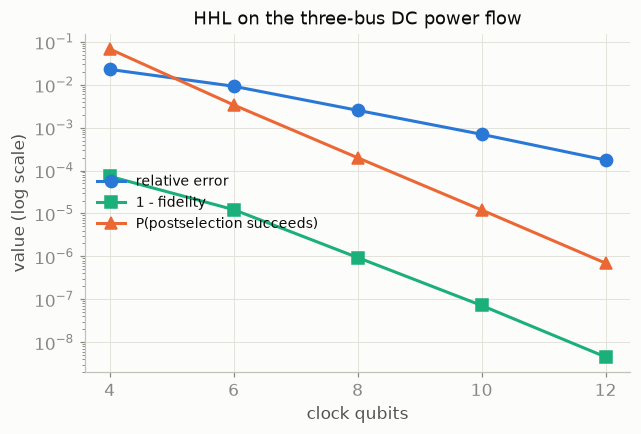

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.semilogy(clock_bits, [sweep[m].decoded["relative_error"] for m in clock_bits],
            "o-", color=qg.viz.PALETTE[0], label="relative error")
ax.semilogy(clock_bits, [1 - sweep[m].decoded["fidelity_vs_exact"] for m in clock_bits],
            "s-", color=qg.viz.PALETTE[2], label="1 - fidelity")
ax.semilogy(clock_bits, [sweep[m].decoded["success_probability"] for m in clock_bits],
            "^-", color=qg.viz.PALETTE[1], label="P(postselection succeeds)")
ax.set_xlabel("clock qubits")
ax.set_ylabel("value (log scale)")
ax.set_xticks(clock_bits)
ax.set_title("HHL on the three-bus DC power flow")
ax.legend(loc="center left", fontsize=9)
plt.show()

Three curves, three different statements, moving in opposite directions.

* **Relative error** — how wrong the angles are, in the units you report. It
  falls by a factor of about 3.4 per two clock bits, from 2.3 percent at four
  clock bits to 0.018 percent at twelve. This is the number a power engineer
  cares about.
* **Fidelity against the exact solution** — how well the *direction* of the
  returned vector matches. It is already 0.999927 at four clock bits, where the
  relative error is still 2.3 percent. Fidelity is nearly blind to the scale
  factor, and HHL’s scale has to be restored classically. A paper reporting only
  fidelity is reporting the easy half of the problem.
* **Postselection probability** — the fraction of hardware runs that survive the
  ancilla measurement. It falls by a factor of about 18 per two clock bits, from
  6.8 percent at four clock bits to `6.9e-7` at twelve. Every failed run is
  discarded, so the number of shots needed grows as fast as this falls. Accuracy
  is bought with runs, not with qubits alone.

Report all three. The pair that matters most is the third against the first: the
same knob that reduces the error makes the answer exponentially rarer.

`clock_leakage` is the amplitude left on clock values other than the correct
eigenvalue after uncomputation. It falls from 0.164 to 0.074 across the sweep —
far more slowly than the relative error — because the two eigenvalues of this
`2 x 2` matrix are not rational multiples of the grid spacing, so they never
land exactly on a grid point no matter how fine the grid is.

## 4.4 Condition number

The **condition number** `kappa` is the ratio of the largest to the smallest
eigenvalue magnitude of `A`. It measures how much the solution moves when the
right-hand side moves. Every quantum linear solver has a runtime that grows
with `kappa`, because the eigenvalue inversion rotates by `1/lambda`, and the
smallest eigenvalue sets the smallest usable rotation.

In [9]:
cases = ("toy3", "case5", "case9", "case14", "case30", "case57", "case118")
sizes, kappas, densities = [], [], []

print(f"{'case':>9} {'unknowns':>9} {'kappa':>10} {'lambda_min':>11} {'lambda_max':>11} "
      f"{'symmetric':>10} {'density':>8}")
for name in cases:
    lp = dc_power_flow(qg.cases.load_case(name))
    eigenvalues = np.linalg.eigvalsh(lp.a)
    density = np.count_nonzero(lp.a) / lp.n**2
    sizes.append(lp.n)
    kappas.append(lp.condition_number())
    densities.append(density)
    print(
        f"{name:>9} {lp.n:>9} {lp.condition_number():>10.1f} {eigenvalues.min():>11.4f} "
        f"{eigenvalues.max():>11.2f} {str(lp.is_hermitian):>10} {density:>8.3f}"
    )

     case  unknowns      kappa  lambda_min  lambda_max  symmetric  density
     toy3         2        3.0     14.4322       43.31       True    1.000
    case5         4       16.2     22.7364      368.01       True    0.625
    case9         8       59.1      0.9123       53.94       True    0.375
   case14        13      119.3      0.5432       64.79       True    0.290
   case30        29      492.5      0.2353      115.91       True    0.127
   case57        56      799.4      0.2107      168.42       True    0.065
  case118       117     2896.1      0.2013      582.93       True    0.034


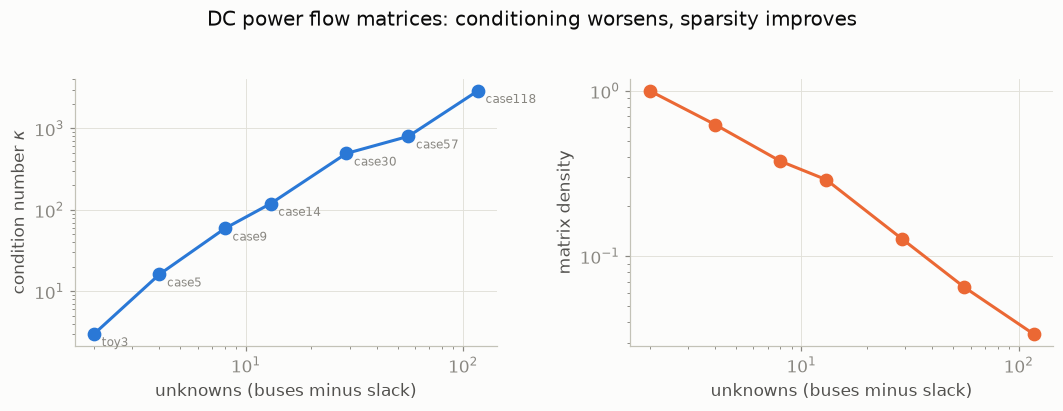

In [10]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.8, 3.6))
left.loglog(sizes, kappas, "o-", color=qg.viz.PALETTE[0])
for name, n, k in zip(cases, sizes, kappas):
    left.annotate(name, (n, k), xytext=(5, -8), textcoords="offset points",
                  fontsize=8, color=qg.viz.MUTED)
left.set_xlabel("unknowns (buses minus slack)")
left.set_ylabel(r"condition number $\kappa$")

right.loglog(sizes, densities, "o-", color=qg.viz.PALETTE[1])
right.set_xlabel("unknowns (buses minus slack)")
right.set_ylabel("matrix density")
fig.suptitle("DC power flow matrices: conditioning worsens, sparsity improves", y=1.03)
plt.tight_layout()
plt.show()

The two panels move in opposite directions as the network grows: the condition
number rises by three orders of magnitude while the matrix density falls by one.
Both trends matter for quantum linear solvers, and they do not cancel.

Two properties of these matrices are genuinely favourable, and one is not.

**Favourable: `B'` is symmetric.** HHL requires a Hermitian matrix. A
non-symmetric system has to be embedded in the larger Hermitian matrix
`[[0, A], [A^T, 0]]`, which doubles the dimension and costs one extra qubit.
`B'` is symmetric already, so that step is skipped. `Result.resources` reports
`hermitian_dilation` so you can see whether it happened.

**Favourable: `B'` is positive definite and sparse.** Every eigenvalue is
positive, so there is no ambiguity of sign in the eigenvalue inversion, and the
matrix density falls from 0.375 at nine buses to 0.034 at 118 buses. Sparsity is
one of the conditions under which HHL’s complexity claim holds at all.

**Not favourable: `kappa` grows with system size.** It runs from 3 on the
three-bus system to about 2900 on the IEEE 118-bus system, driven by the
smallest eigenvalue falling toward 0.2 while the largest keeps growing. HHL’s
cost scales polynomially in `kappa`, so “power flow matrices are well
conditioned” is only true relative to a general dense system. At realistic
transmission-system sizes `kappa` is in the thousands, and that is a cost, not a
footnote.

The effect is measurable directly: hold the clock register fixed and increase
the system size.

In [11]:
print(f"{'case':>8} {'unknowns':>9} {'kappa':>8} {'rel. error':>12} {'fidelity':>10} "
      f"{'P(success)':>12}")
for name in ("toy3", "case5", "case9", "case14"):
    lp = dc_power_flow(qg.cases.load_case(name))
    out = qg.solve(lp, solver="hhl", n_clock=8)
    d = out.decoded
    print(
        f"{name:>8} {lp.n:>9} {lp.condition_number():>8.1f} {d['relative_error']:>12.2e} "
        f"{d['fidelity_vs_exact']:>10.6f} {d['success_probability']:>12.2e}"
    )

    case  unknowns    kappa   rel. error   fidelity   P(success)
    toy3         2      3.0     2.53e-03   0.999999     1.99e-04
   case5         4     16.2     6.97e-03   0.999977     2.63e-03
   case9         8     59.1     2.66e-02   0.999797     1.66e-03
  case14        13    119.3     5.11e-02   0.999978     1.74e-01


With eight clock qubits fixed, the relative error grows from `2.5e-3` on the
three-bus system to `5.1e-2` on the 14-bus system — a factor of 20 for a factor
of 40 in condition number. Holding accuracy constant as the system grows means
adding clock qubits, which by section 4.3 means paying exponentially more shots.

The postselection column does not follow the same trend, and should not be
expected to. It is set by how the eigenvalue spectrum happens to line up with
the clock grid and by the eigenvalue inversion constant, not by system size, so
it moves between `2e-4` and `0.17` across these four cases without an ordering.

VQLS degrades faster still, and for a different reason.

In [12]:
for name in ("toy3", "case9"):
    lp = dc_power_flow(qg.cases.load_case(name))
    out = qg.solve(lp, solver="vqls", layers=3, maxiter=1200, seed=0)
    d = out.decoded
    print(
        f"{name:>7} n={lp.n:<3} relative error {d['relative_error']:.3e}  "
        f"fidelity {d['fidelity_vs_exact']:.4f}  final cost {d['final_cost']:.2e}  "
        f"parameters {out.resources['parameters']}"
    )

   toy3 n=2   relative error 1.671e-05  fidelity 1.0000  final cost 1.03e-10  parameters 4


  case9 n=8   relative error 9.308e-01  fidelity 0.5426  final cost 5.88e-03  parameters 12


VQLS is exact on the three-bus system and fails on the nine-bus system, with a
relative error near 1 and fidelity near 0.5 — no better than an arbitrary
direction. The ansatz is not the limitation: with three qubits it can represent
any real eight-dimensional direction, and adding layers does not help. The
limitation is the cost function. QuGrid uses the *global* cost from
Bravo-Prieto et al., which the same paper documents as training poorly as the
system grows, because the gradient signal shrinks with dimension. Local cost
functions and better initialization strategies are an active research topic;
this measurement is the reason they exist, not an argument that VQLS cannot
work.

## 4.5 AC power flow with a quantum inner solver

Newton-Raphson AC power flow solves `J dx = -F` at every iteration, where `J` is
the Jacobian and `F` the power mismatch. Replace that inner solve and the rest
of the algorithm is unchanged. This hybrid decomposition — classical outer loop,
quantum inner solve — is the standard proposal for quantum power flow.

`newton_with_linear_solver(net, solve_fn)` takes any function that maps a
`LinearSystemProblem` to a solution vector.

In [13]:
def scientific(values) -> str:
    return "  ".join(f"{v:.2e}" for v in values)


case9 = qg.cases.case9()

started = time.perf_counter()
hybrid = newton_with_linear_solver(case9, lambda step: np.linalg.solve(step.a, step.b))
elapsed = time.perf_counter() - started

print(f"converged: {hybrid.ac.converged} in {hybrid.ac.iterations} iterations, "
      f"{hybrid.linear_solves} linear solves, {1000 * elapsed:.1f} ms")
print("power mismatch per iteration [pu]:", scientific(hybrid.ac.mismatch_history))
print("inner residuals ||J dx + F||     :", scientific(hybrid.inner_residuals))

converged: True in 4 iterations, 3 linear solves, 0.3 ms
power mismatch per iteration [pu]: 1.63e+00  1.88e-01  2.15e-03  3.42e-07
inner residuals ||J dx + F||     : 4.94e-16  1.30e-16  1.22e-18


The mismatch falls from 1.6 to `3e-7` per unit in four iterations, roughly
squaring the number of correct digits each time. That is Newton’s quadratic
convergence, and it is fragile: it depends on each inner solve being accurate.
An inner solver that returns a 5 percent error destroys it, and the outer loop
either stalls or needs many more iterations.

Swap in VQLS on the three-bus system, where section 4.4 showed it is accurate,
and the quadratic convergence survives.

In [14]:
started = time.perf_counter()
quantum_inner = newton_with_linear_solver(
    qg.cases.toy3(),
    lambda step: solve_vqls(step, layers=3, maxiter=400, restarts=2, seed=0).x,
)
elapsed = time.perf_counter() - started

print(f"converged: {quantum_inner.ac.converged} in {quantum_inner.ac.iterations} iterations, "
      f"{quantum_inner.linear_solves} VQLS calls, {1000 * elapsed:.0f} ms")
print("power mismatch per iteration [pu]:", scientific(quantum_inner.ac.mismatch_history))
print("inner residuals ||J dx + F||     :", scientific(quantum_inner.inner_residuals))

exact_ac = qg.classical.newton_raphson(qg.cases.toy3())
print("\nvoltage magnitudes match classical Newton:",
      np.allclose(quantum_inner.ac.vm, exact_ac.vm, atol=1e-8))
print("voltage angles [degree]:", np.rad2deg(quantum_inner.ac.va))

converged: True in 4 iterations, 3 VQLS calls, 672 ms
power mismatch per iteration [pu]: 1.50e+00  4.68e-02  1.26e-04  1.92e-08
inner residuals ||J dx + F||     : 5.44e-04  4.26e-06  2.53e-08

voltage magnitudes match classical Newton: True
voltage angles [degree]: [ 0.     -0.5267 -3.4537]


Same iteration count, same answer to eight decimal places. Note what the
Jacobian is not: it is not symmetric, so HHL applied here would pay the
Hermitian dilation and one extra qubit, whereas VQLS handles a non-symmetric
matrix directly. Note also what the timing says — about 670 milliseconds for
three inner solves of a `3 x 3` system.

## 4.6 The comparison that matters

Sparse LU factorization is what production power flow software actually uses.
Measure it on the same matrices.

In [15]:
print(f"{'case':>8} {'unknowns':>9} {'nonzeros':>9} {'sparse LU solve':>17}")
for name in ("case9", "case118"):
    lp = dc_power_flow(qg.cases.load_case(name))
    matrix = sp.csc_matrix(lp.a)
    factorization = spla.splu(matrix)
    started = time.perf_counter()
    for _ in range(200):
        factorization.solve(lp.b)
    micros = 1e6 * (time.perf_counter() - started) / 200
    print(f"{name:>8} {lp.n:>9} {matrix.nnz:>9} {micros:>14.1f} us")

    case  unknowns  nonzeros   sparse LU solve
   case9         8        24            1.8 us
 case118       117       463            3.1 us


Three microseconds for the IEEE 118-bus system, on one core of a laptop, after a
factorization that is reused across right-hand sides. **No quantum linear solver
available today, or in any near-term projection, competes with that.** Say so in
any paper that reports the experiments in this notebook.

Three specific obstacles stand between the algorithm and a useful speedup, and
all three are visible above:

* **Readout.** HHL leaves the answer in the amplitudes of a quantum state. Any
  claimed speedup assumes you need a summary of `x` — one inner product, one
  norm — rather than all of it. Power flow needs all the angles, and reading `n`
  amplitudes takes at least `n` measurements, which cancels the exponential.
* **State preparation.** Loading `b` into amplitudes is assumed free in the
  complexity statement. For an arbitrary injection vector it is not.
* **Postselection and conditioning.** Section 4.3 measured the shot cost of
  accuracy; section 4.4 measured how `kappa` grows with system size.

So where is the research? In exactly the quantities this notebook computes.
Error and resource analysis for realistic power system matrices is publishable
work that needs no hardware: how `kappa` scales with network topology, how many
clock qubits a target angle accuracy demands, which power system questions need
only a scalar functional of `x` and therefore survive the readout objection, and
how a hybrid Newton loop tolerates inner-solver error.

The starting points in the power system literature:

* F. Feng, Y. Zhou, P. Zhang, “Quantum Power Flow”, IEEE Transactions on Power
  Systems, volume 36, number 4, 2021, arXiv:2104.04888 — HHL applied to power
  flow, with the error analysis this notebook reproduces in miniature.
* R. Eskandarpour et al., “Quantum-Enhanced Grid of the Future: A Primer”, IEEE
  Access, volume 8, 2020 — the survey of where quantum algorithms touch power
  system computation.

## 4.7 Summary

* `dc_power_flow(net)` builds `B' theta = P` with the slack bus eliminated. The
  result is symmetric, positive definite, and sparse.
* `qg.solve` runs `numpy`, `hhl`, or `vqls` on it, and every one returns the
  same `Result` type.
* HHL error has three faces: relative error, fidelity, and postselection
  probability. Adding clock qubits improves the first two and destroys the
  third.
* The condition number of `B'` grows from 3 to about 2900 between three and 118
  buses, and quantum linear solver cost grows with it.
* A hybrid Newton loop keeps quadratic convergence only while the inner solves
  stay accurate.

Notebook 5 turns to the third family, machine learning, applied to N-1 security
screening.